# 02 — MBA-Relevant Occupation Analysis

Narrowing the full H-1B/PERM dataset down to roles an MBA graduate can realistically target,
and starting to answer the recruiting-strategy questions: which employers, which functions,
which locations give an international MBA the best odds of sponsorship.

**Important caveat**: neither disclosure file includes a minimum-degree-required field (PERM's
public extract only has `OCCUPATION_TYPE`: Professional / Non-professional / College-University
Teacher — it drops the more detailed education fields DOL collects internally). So "MBA-relevant"
here is a SOC-code + title heuristic (see `src/mba_occupations.py`), not a hard filter on actual
degree requirements. Treat tier splits as directional, not exact.

Data now spans full FY2025 plus FY2026 through Q3, so we can start asking not just "who
sponsors MBA-relevant roles" but "is that pool growing or shrinking" — relevant given how fast
the sponsorship landscape has been moving.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from mba_occupations import classify_mba_relevance  # noqa: E402
from employer_canonicalization import add_canonical_employer  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"

In [2]:
lca = load_lca()
perm = load_perm()

lca["MBA_TIER"] = classify_mba_relevance(lca["SOC_CODE"], lca["SOC_TITLE"])
perm["MBA_TIER"] = classify_mba_relevance(perm["PWD_SOC_CODE"], perm["PWD_SOC_TITLE"])

lca = add_canonical_employer(lca, "EMPLOYER_NAME", "EMPLOYER_CANONICAL")
perm = add_canonical_employer(perm, "EMP_BUSINESS_NAME", "EMPLOYER_CANONICAL")

## How much of the market is actually MBA-relevant?

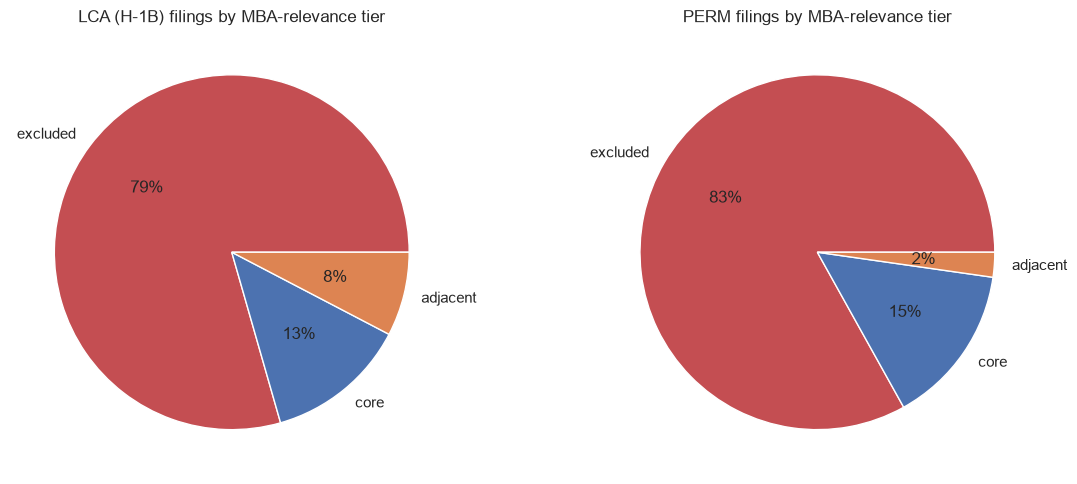

LCA:
 MBA_TIER
excluded    813144
core        132124
adjacent     78371
Name: count, dtype: int64 

PERM:
 MBA_TIER
excluded    215601
core         38029
adjacent      5859
Name: count, dtype: int64


In [3]:
lca_tier_counts = lca["MBA_TIER"].value_counts()
perm_tier_counts = perm["MBA_TIER"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_tier_counts.plot.pie(ax=axes[0], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[0].set_title("LCA (H-1B) filings by MBA-relevance tier")
perm_tier_counts.plot.pie(ax=axes[1], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[1].set_title("PERM filings by MBA-relevance tier")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_tier_share.png", dpi=150)
plt.show()

print("LCA:\n", lca_tier_counts, "\n")
print("PERM:\n", perm_tier_counts)

In [4]:
lca_mba = lca[lca["MBA_TIER"] != "excluded"].copy()
perm_mba = perm[perm["MBA_TIER"] != "excluded"].copy()
print(f"MBA-relevant LCA filings: {len(lca_mba):,} ({len(lca_mba) / len(lca):.1%} of all)")
print(f"MBA-relevant PERM filings: {len(perm_mba):,} ({len(perm_mba) / len(perm):.1%} of all)")

MBA-relevant LCA filings: 210,495 (20.6% of all)
MBA-relevant PERM filings: 43,888 (16.9% of all)


## Is the MBA-relevant pool growing or shrinking? FY2025 vs FY2026 (Q1-Q3 only, for a fair
comparison against FY2026's partial year)


LCA (H-1B) — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):
MBA_TIER      core  adjacent  excluded
FISCAL_YEAR                           
2025         49750     37867    381832
2026         66781     31578    339137
  core: +34.2% YoY
  adjacent: -16.6% YoY



PERM — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):
MBA_TIER      core  adjacent  excluded
FISCAL_YEAR                           
2025         13830      2172     85001
2026         17207      2618     92725
  core: +24.4% YoY
  adjacent: +20.5% YoY


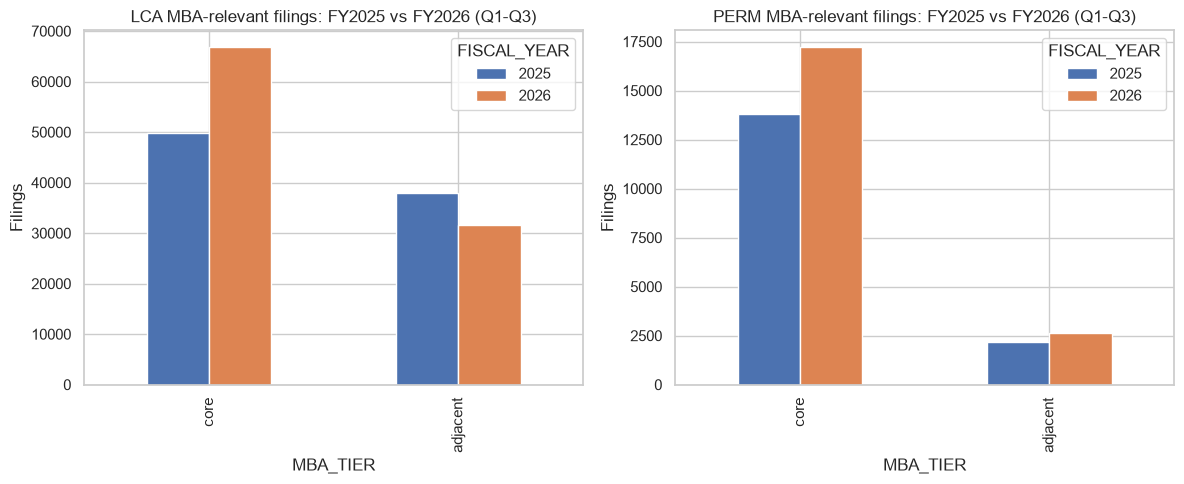

In [5]:
def mba_yoy_by_quarter(df, label):
    q13 = df[df["FISCAL_QUARTER"] <= 3]
    g = q13.groupby(["FISCAL_YEAR", "MBA_TIER"]).size().unstack(fill_value=0)
    g = g.reindex(columns=["core", "adjacent", "excluded"], fill_value=0)
    print(f"\n{label} — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):")
    print(g)
    for tier in ["core", "adjacent"]:
        if 2025 in g.index and 2026 in g.index and g.loc[2025, tier] > 0:
            pct = (g.loc[2026, tier] / g.loc[2025, tier] - 1) * 100
            print(f"  {tier}: {pct:+.1f}% YoY")
    return g


lca_mba_yoy = mba_yoy_by_quarter(lca, "LCA (H-1B)")
perm_mba_yoy = mba_yoy_by_quarter(perm, "PERM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_mba_yoy[["core", "adjacent"]].T.plot.bar(ax=axes[0])
axes[0].set_title("LCA MBA-relevant filings: FY2025 vs FY2026 (Q1-Q3)")
axes[0].set_ylabel("Filings")
perm_mba_yoy[["core", "adjacent"]].T.plot.bar(ax=axes[1])
axes[1].set_title("PERM MBA-relevant filings: FY2025 vs FY2026 (Q1-Q3)")
axes[1].set_ylabel("Filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_yoy.png", dpi=150)
plt.show()

## Certification rate: does it differ by tier?

If core/adjacent roles get certified at a similar (or better) rate than the broader market,
that's reassuring — it means the bottleneck for MBAs isn't the process, it's finding
employers who file for these roles at all.

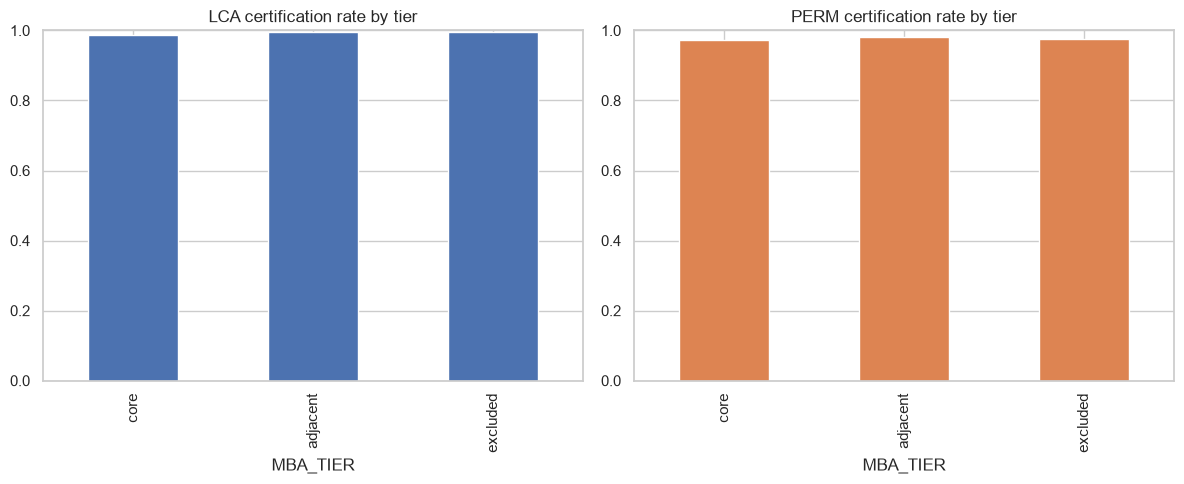

In [6]:
def cert_rate_by_tier(df, decided_statuses, denied_status="Denied"):
    decided = df[df["CASE_STATUS"].isin(decided_statuses)]
    return decided.groupby("MBA_TIER")["CASE_STATUS"].apply(lambda s: (s != denied_status).mean())


lca_cert_by_tier = cert_rate_by_tier(lca, ["Certified", "Certified - Withdrawn", "Denied"])
perm_cert_by_tier = cert_rate_by_tier(perm, ["Certified", "Certified - Expired", "Denied"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("LCA certification rate by tier")
axes[0].set_ylim(0, 1)
perm_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("PERM certification rate by tier")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_cert_rate_by_tier.png", dpi=150)
plt.show()

## Which functions within "core" and "adjacent" see the most volume?

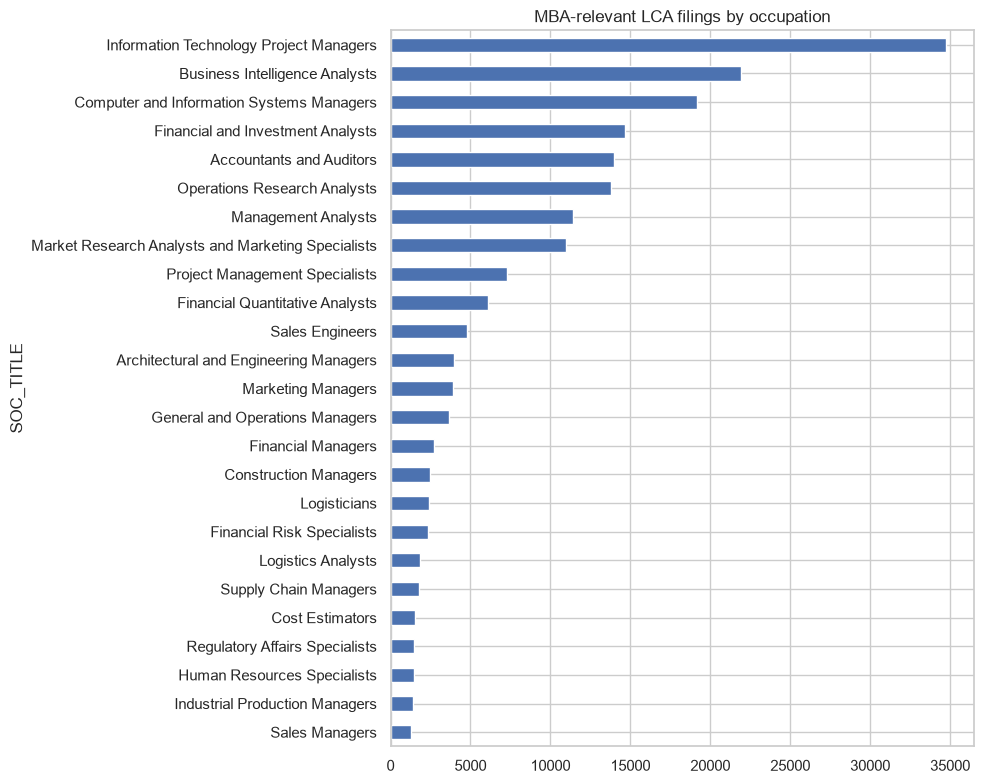

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
lca_mba["SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_lca.png", dpi=150)
plt.show()

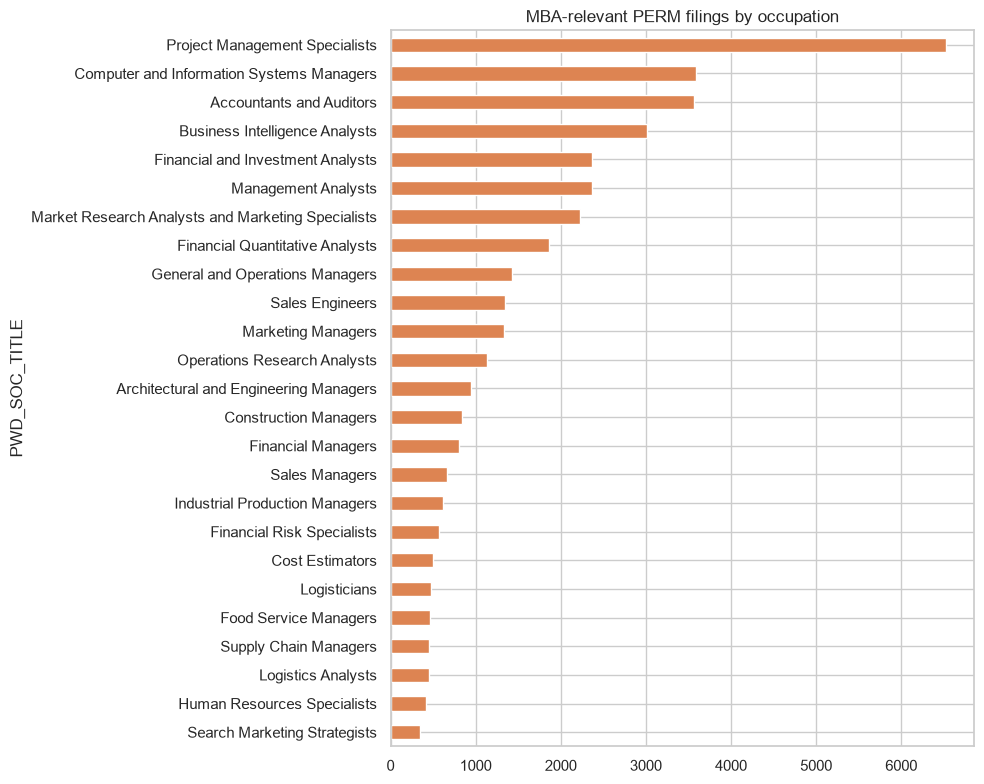

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
perm_mba["PWD_SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#DD8452")
ax.set_title("MBA-relevant PERM filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_perm.png", dpi=150)
plt.show()

## Top employers sponsoring MBA-relevant roles

This is the recruiting-strategy payload: which companies are actually filing for business/
management-track roles (as opposed to being a huge H-1B filer purely on the engineering side).

In [9]:
top_employers_lca_mba = lca_mba["EMPLOYER_CANONICAL"].value_counts().head(30)
top_employers_lca_mba

EMPLOYER_CANONICAL
Amazon.com Services LLC                         9555
Ernst & Young U.S. LLP                          6282
INFOSYS LIMITED                                 3185
Google LLC                                      2174
Microsoft Corporation                           2064
JPMorgan Chase & Co.                            1992
Deloitte Consulting LLP                         1848
Apple Inc.                                      1843
Meta Platforms, Inc                             1583
GOLDMAN SACHS & CO. LLC                         1491
WAL-MART ASSOCIATES, INC.                       1431
Deloitte Tax LLP                                1338
COGNIZANT TECHNOLOGY SOLUTIONS US CORP          1284
Deloitte & Touche LLP                           1275
HCL AMERICA INC                                 1258
Amazon Web Services, Inc.                       1216
Boston Consulting Group, Inc.                   1032
PRICEWATERHOUSECOOPERS ADVISORY SERVICES LLC    1021
Accenture LLP              

In [10]:
top_employers_perm_mba = perm_mba["EMPLOYER_CANONICAL"].value_counts().head(30)
top_employers_perm_mba

EMPLOYER_CANONICAL
Microsoft Corporation                           780
Ernst & Young U.S. LLP                          575
MCKINSEY & COMPANY, INC. UNITED STATES          459
JPMORGAN CHASE & CO.                            373
Goldman Sachs & Co. LLC                         370
THE BOSTON CONSULTING GROUP, INC.               351
Deloitte Consulting LLP                         349
WAL-MART ASSOCIATES, INC.                       307
Accenture LLP                                   302
Citibank, N.A.                                  264
TATA CONSULTANCY SERVICES LIMITED               258
Salesforce, Inc.                                239
Uber Technologies, Inc.                         216
TESLA, INC.                                     166
Cisco Systems, Inc.                             156
ByteDance Inc.                                  155
Deloitte Tax LLP                                152
FMR LLC                                         151
Adobe Inc.                                   

### "MBA-focused" employers: high share of MBA-relevant filings, not just high volume

A employer with 5 total filings, all core-MBA roles, is a better lead than one with 500
filings where only 2% are business-track. Rank by volume *and* mix.

In [11]:
def employer_mba_mix(df, employer_col, min_filings=10):
    g = df.groupby(employer_col)["MBA_TIER"].agg(
        total="count",
        mba_relevant=lambda s: (s != "excluded").sum(),
    )
    g["mba_share"] = g["mba_relevant"] / g["total"]
    return g[g["total"] >= min_filings].sort_values(["mba_share", "total"], ascending=False)


lca_employer_mix = employer_mba_mix(lca, "EMPLOYER_CANONICAL")
lca_employer_mix.head(25)

,total,mba_relevant,mba_share
EMPLOYER_CANONICAL,,,
"Alvarez & Marsal Consumer and Retail Group, LLC",34,34,1.0
PWP Employer LP,24,24,1.0
EASY SURFACES CORPORATION,23,23,1.0
APPLICATIONS SOFTWARE TECHNOLOGY LLC,21,21,1.0
DIA Associates LLC,20,20,1.0
OC&C Strategy Consultants USA Inc.,19,19,1.0
KKR Capstone Americas LLC,18,18,1.0
"Arthur D. Little, LLC",17,17,1.0
Host & Company III LLC,17,17,1.0


In [12]:
perm_employer_mix = employer_mba_mix(perm, "EMPLOYER_CANONICAL")
perm_employer_mix.head(25)

,total,mba_relevant,mba_share
EMPLOYER_CANONICAL,,,
"BDO USA, P.C. (FKA BDO USA, LLP)",47,47,1.000000
EVERCORE PARTNERS SERVICES EAST LLC,34,34,1.000000
SQUAREPOINT SERVICES US LLC,26,26,1.000000
"BDO USA, P.C.",21,21,1.000000
Macias Gini & O'Connell LLP,17,17,1.000000
The Siegfried Group LLP,15,15,1.000000
Spike Inc.,14,14,1.000000
"Bayview Asset Management, LLC",13,13,1.000000
Funaro & Co. PC,13,13,1.000000


## Wage premium for MBA-relevant roles

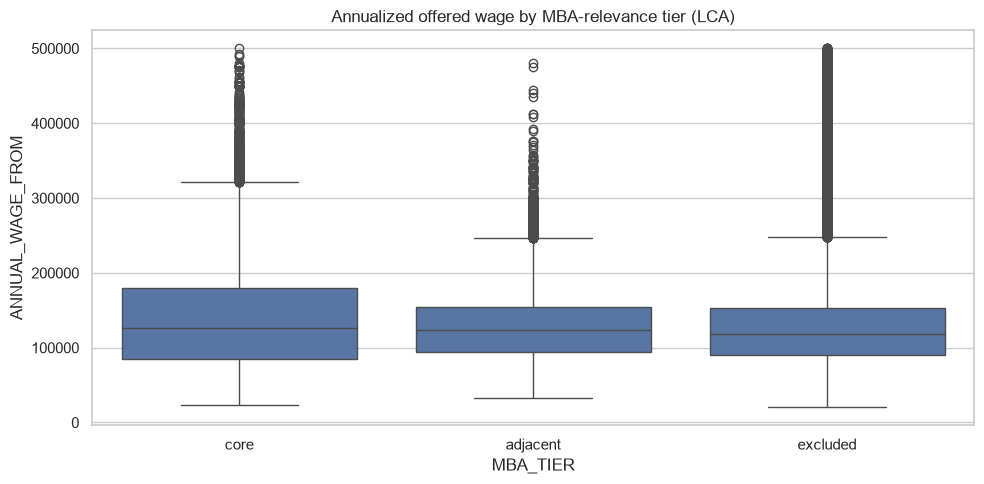

,count,mean,std,min,25%,50%,75%,max
MBA_TIER,,,,,,,,
adjacent,46660.0,129038.817634,44066.693227,33030.0,94037.0,124005.0,155000.0,480000.00
core,64992.0,138405.435889,65145.287222,24000.0,85238.3,126125.5,179700.0,499999.00
excluded,471639.0,127875.350448,52958.139499,20280.0,90168.0,117800.0,153301.0,499999.92


In [13]:
lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca_wage = lca[(lca["ANNUAL_WAGE_FROM"] > 20_000) & (lca["ANNUAL_WAGE_FROM"] < 500_000)]

fig, ax = plt.subplots()
sns.boxplot(data=lca_wage, x="MBA_TIER", y="ANNUAL_WAGE_FROM", order=["core", "adjacent", "excluded"], ax=ax)
ax.set_title("Annualized offered wage by MBA-relevance tier (LCA)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_wage_by_tier.png", dpi=150)
plt.show()

lca_wage.groupby("MBA_TIER")["ANNUAL_WAGE_FROM"].describe()

## Geographic concentration of MBA-relevant sponsorship

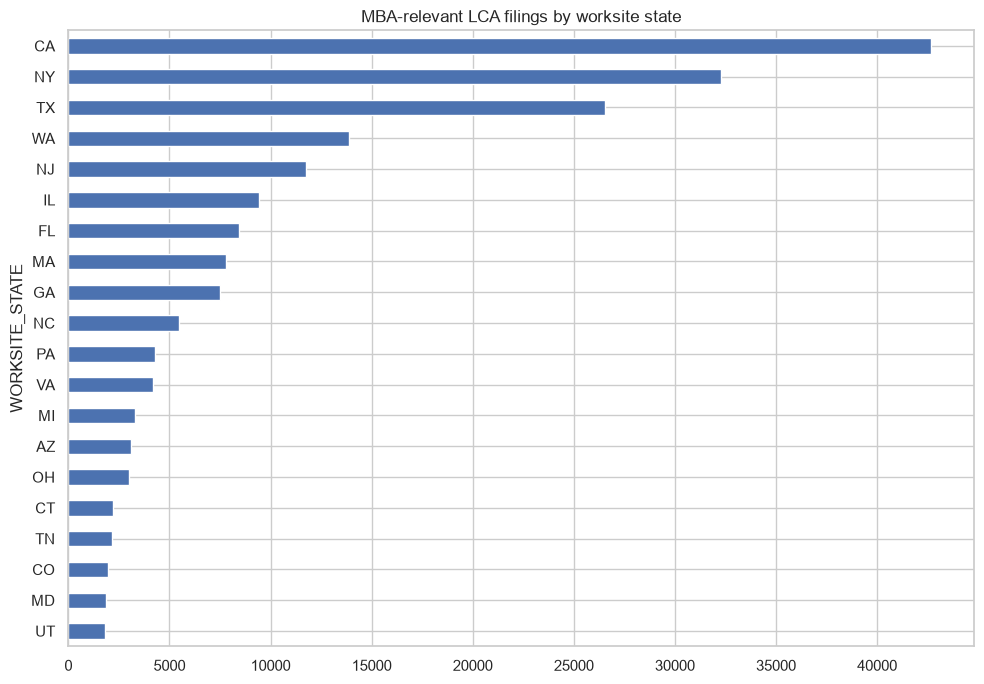

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
lca_mba["WORKSITE_STATE"].value_counts().head(20).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by worksite state")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_states.png", dpi=150)
plt.show()

## Save dashboard-ready aggregates

In [15]:
lca_employer_mix.reset_index().to_csv(PROCESSED_DIR / "lca_employer_mba_mix.csv", index=False)
perm_employer_mix.reset_index().to_csv(PROCESSED_DIR / "perm_employer_mba_mix.csv", index=False)
lca_mba["SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_occupations.csv")
perm_mba["PWD_SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "perm_mba_occupations.csv")
lca_mba["WORKSITE_STATE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_states.csv")

print("Saved MBA-focused aggregates to", PROCESSED_DIR)

Saved MBA-focused aggregates to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Notes for next session

- Need a better MBA-relevance signal than SOC/title regex — worth checking whether the DOL
  PERM *case-level* disclosure (not this summary extract) exposes minimum education fields we
  could join in, or whether O*NET's "typical education" lookup by SOC code is a cleaner proxy.
- Employer names are canonicalized for casing/punctuation/legal-suffix noise (see
  `src/employer_canonicalization.py`), but distinct legal subsidiaries of the same brand (e.g.
  Amazon Web Services, Inc. vs Amazon.com Services LLC) are intentionally left separate — that
  needs a manually-curated brand alias list, scoped to just the top employers on the dashboard
  leaderboard, rather than automated fuzzy matching (which produces false merges, e.g. "Apple
  American Group LLC" is an Applebee's franchisee, not Apple Inc.).
- Should link LCA employer names to PERM employer names (fuzzy match — names aren't identical
  across the two systems) to see which employers do *both* H-1B and green card sponsorship for
  business roles, since that end-to-end path is what students actually care about.
- Consider NAICS industry rollups on top of the occupation tiers (e.g. consulting/finance/tech
  sector cuts) for the dashboard's employer targeting view.